**Objective**
- Demonstrate multiple image segmentation techniques.
- Compare results visually.
- Understand strengths and limitations of each method.

**Import Libraries**

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import segmentation, color

**Load Image**

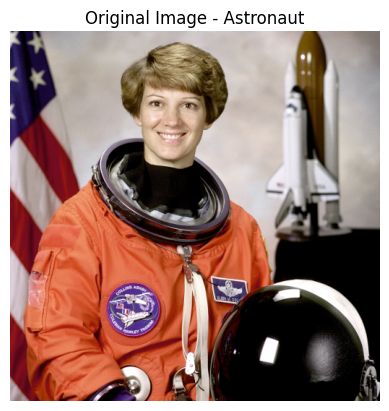

In [16]:
# Install required libraries (if not already installed)
!pip install scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Step 3: Load Image (Astronaut sample image)
image = data.astronaut()  # Publicly available sample image

# Display the image
plt.imshow(image)
plt.title("Original Image - Astronaut")
plt.axis('off')
plt.show()

**Segmentation Techniques**

- Thresholding (Otsu’s Method)

In [17]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

_, otsu = cv2.threshold(gray, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)

2. Region-Based Segmentation (Simple Region Growing)

In [18]:
def region_growing(img, seed):
    h, w = img.shape
    segmented = np.zeros((h, w), np.uint8)
    threshold = 10

    stack = [seed]
    while stack:
        x, y = stack.pop()
        if segmented[x, y] == 0:
            segmented[x, y] = 255
            for dx in [-1,0,1]:
                for dy in [-1,0,1]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if abs(int(img[nx, ny]) - int(img[x, y])) < threshold:
                            stack.append((nx, ny))
    return segmented

region = region_growing(gray, (100, 100))

3. Clustering-Based Segmentation (K-Means)

In [19]:
pixel_vals = image.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(pixel_vals)

segmented_kmeans = labels.reshape(image.shape[:2])

4. Graph-Based Segmentation (GrabCut)

In [20]:
mask = np.zeros(image.shape[:2], np.uint8)

bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

rect = (50, 50, 300, 300)

cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
grabcut = image * mask2[:,:,np.newaxis]

5. Watershed Algorithm

In [21]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
_, thresh = cv2.threshold(gray, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0

markers = cv2.watershed(image, markers)

watershed = image.copy()
watershed[markers == -1] = [255, 0, 0]

5: Visualization (All Results)

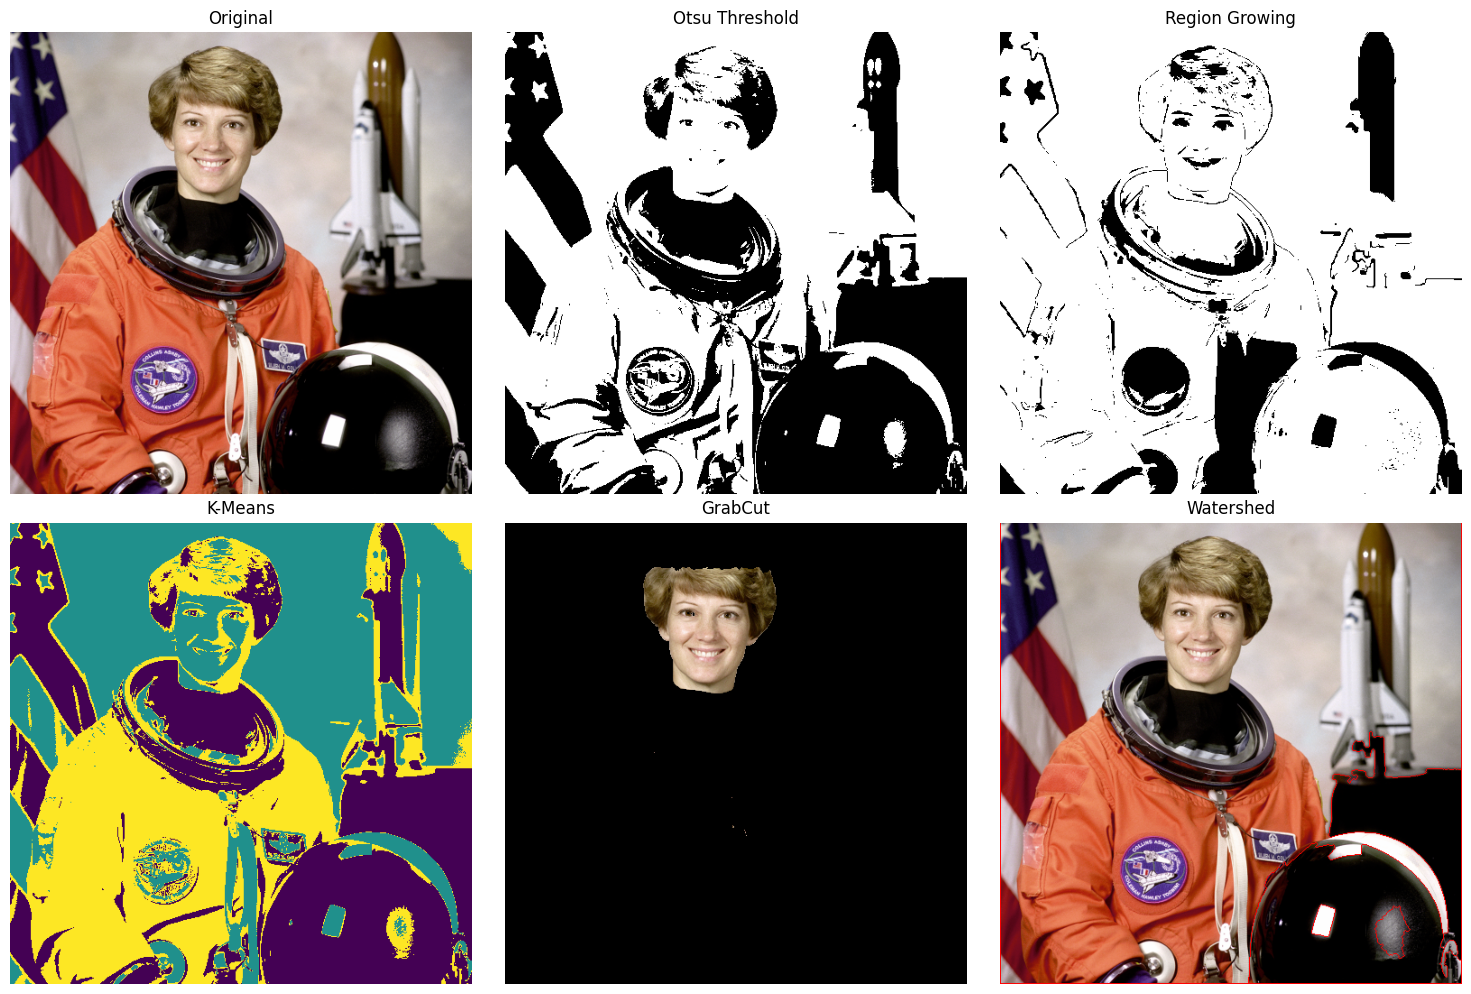

In [22]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(otsu, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(region, cmap='gray')
plt.title("Region Growing")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(segmented_kmeans, cmap='viridis')
plt.title("K-Means")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(grabcut)
plt.title("GrabCut")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(watershed)
plt.title("Watershed")
plt.axis('off')

plt.tight_layout()
plt.show()